Importing the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

Loading the dataset

In [4]:
df = pd.read_csv("/content/netflix_titles.csv")

Explore

In [18]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [19]:
print("Shape of dataset:", df.shape)

Shape of dataset: (8807, 12)


In [20]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8800 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [22]:
df.describe()

,date_added,release_year
count,8709,8807.000000
mean,2019-05-23 01:45:29.452290816,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-20 00:00:00,2013.000000
50%,2019-07-12 00:00:00,2017.000000
75%,2020-08-26 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [23]:
df.describe(include="object")

,show_id,type,title,director,cast,country,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8800,8807,8807,8807
unique,8807,2,8807,4528,7692,748,14,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,3207,1793,362,4


In [24]:
# Check missing values
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        98
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64


In [25]:
# Missing value percentage
missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent[missing_percent > 0])

director      29.908028
cast           9.367549
country        9.435676
date_added     1.112751
rating         0.079482
dtype: float64


In [26]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check duplicate show IDs
print("Duplicate show IDs:", df["show_id"].duplicated().sum())

Duplicate rows: 0
Duplicate show IDs: 0


### Duplicate Record Analysis

The dataset contains 0 duplicate rows and 0 duplicate show IDs.
This indicates that there are no exact duplicate records or
repeated show identifiers in the dataset.

In [27]:
# Check unique values in categorical columns
for col in ["type", "rating"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

# Check duration formats
print("\nDuration examples:")
print(df["duration"].head(10))

# Check release year range
print("\nRelease year range:")
print(df["release_year"].min(), df["release_year"].max())


type:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

rating:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
NaN            7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

Duration examples:
0       90 min
1    2 Seasons
2     1 Season
3     1 Season
4    2 Seasons
5     1 Season
6       91 min
7      125 min
8    9 Seasons
9      104 min
Name: duration, dtype: object

Release year range:
1925 2021


### Data Quality Analysis

The dataset contains 6,131 Movies and 2,676 TV Shows.
Movies account for approximately 69.6% of the total titles.

TV-MA is the most common content rating, followed by TV-14.
The duration column contains both movie durations in minutes
and TV Show durations in seasons.

The release years range from 1925 to 2021. The rating column
contains 7 missing values, which will be considered during
data cleaning.

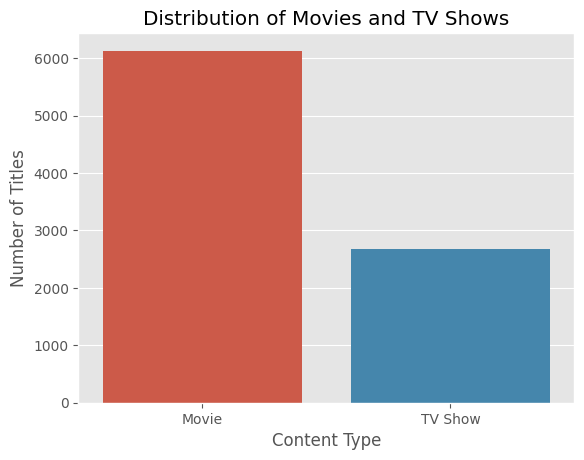

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="type", hue="type", legend=False)

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

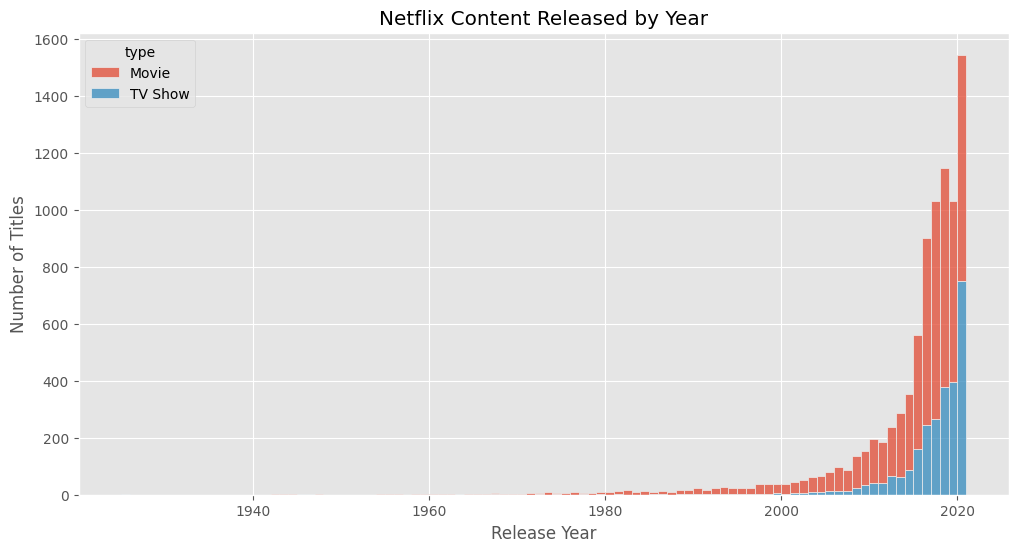

In [29]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="release_year",
    hue="type",
    multiple="stack",
    binwidth=1
)

plt.title("Netflix Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()


The analysis shows that Netflix's catalog contains a large number of titles released in recent years. The number of titles increases considerably after 2015, with movies contributing the largest share. The distribution suggests that the dataset is concentrated more heavily on recent releases than on older titles.

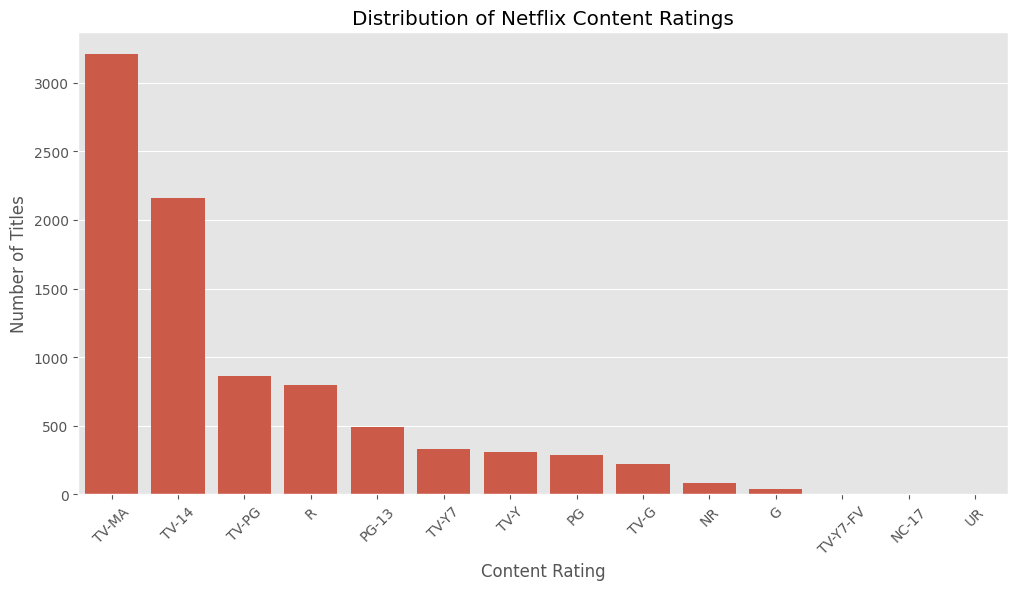

In [30]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="rating",
    order=df["rating"].value_counts().index
)

plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Content Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

The analysis shows that TV-MA is the most common content rating on Netflix, followed by TV-14. This indicates that a substantial portion of the titles in the dataset is classified for mature or teenage audiences. Family-oriented ratings such as TV-Y and TV-G are also present, but occur less frequently than TV-MA and TV-14.

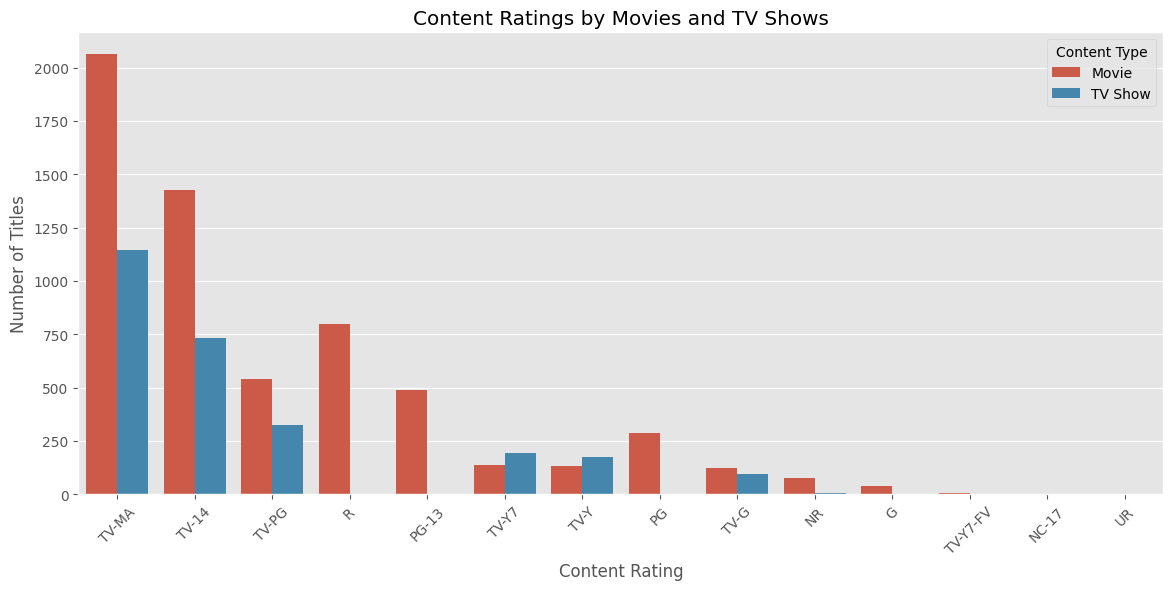

In [31]:
plt.figure(figsize=(14, 6))

sns.countplot(
    data=df,
    x="rating",
    hue="type",
    order=df["rating"].value_counts().index
)

plt.title("Content Ratings by Movies and TV Shows")
plt.xlabel("Content Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Content Type")
plt.show()

The comparison shows that TV-MA and TV-14 are the most common ratings for both movies and TV shows. Movies have a larger number of titles rated R and PG-13, while TV shows have a greater presence in child-oriented categories such as TV-Y and TV-Y7. This highlights differences in the rating distributions of the two content types.

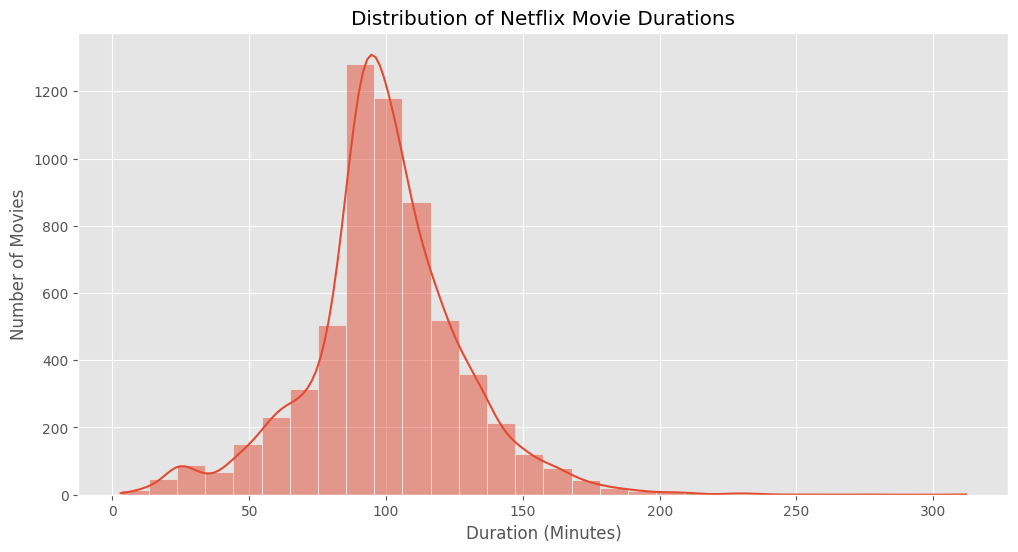

In [32]:
# Extract movie durations in minutes
movies = df[df["type"] == "Movie"].copy()

movies["duration_minutes"] = (
    movies["duration"]
    .str.replace(" min", "", regex=False)
    .astype(float)
)

plt.figure(figsize=(12, 6))

sns.histplot(
    data=movies,
    x="duration_minutes",
    bins=30,
    kde=True
)

plt.title("Distribution of Netflix Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

The analysis shows that most Netflix movies have a duration of approximately 90–100 minutes, with a large proportion falling between 80 and 120 minutes. The distribution is right-skewed, indicating that a smaller number of movies have significantly longer durations.

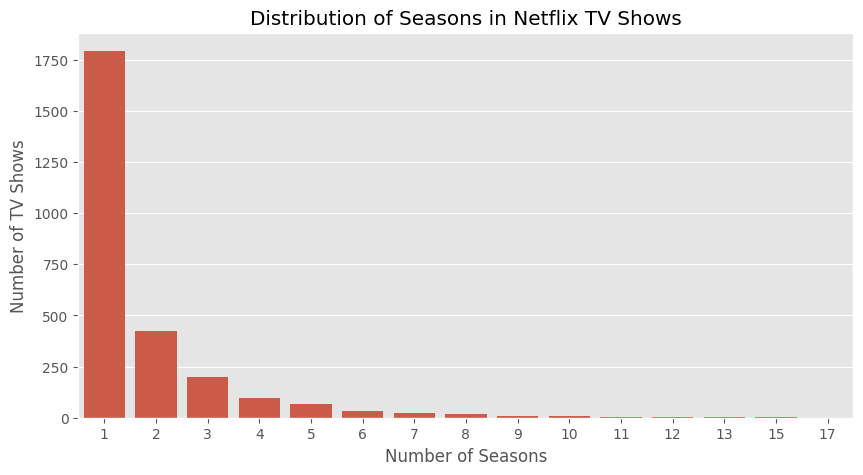

In [33]:
# Filter TV Shows
tv_shows = df[df["type"] == "TV Show"].copy()

# Extract number of seasons
tv_shows["seasons"] = (
    tv_shows["duration"]
    .str.replace(" Season", "", regex=False)
    .str.replace("s", "", regex=False)
    .astype(int)
)

plt.figure(figsize=(10, 5))

sns.countplot(
    data=tv_shows,
    x="seasons",
    order=sorted(tv_shows["seasons"].unique())
)

plt.title("Distribution of Seasons in Netflix TV Shows")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.show()

The analysis shows that most Netflix TV shows have only one season. The number of shows decreases as the number of seasons increases, indicating that multi-season shows are less common in the dataset. Only a small number of shows have 10 or more seasons.

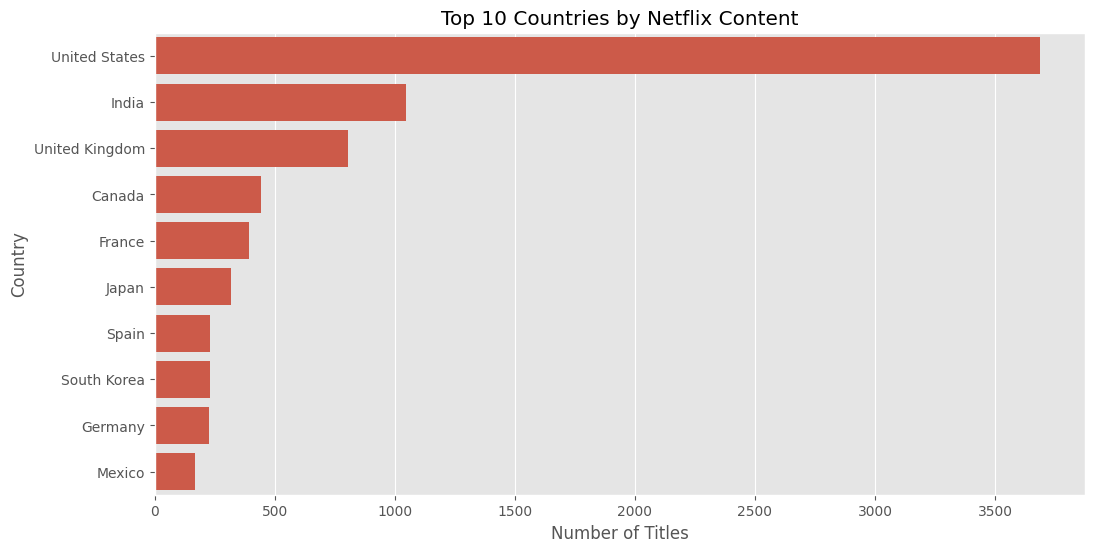

In [34]:
# Split countries and count titles
country_counts = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

The analysis shows that the United States contributes the largest number of titles to Netflix's catalog, followed by India and the United Kingdom. Other countries, including Canada, France, Japan, and South Korea, also contribute to the dataset. This demonstrates that Netflix's catalog includes content associated with countries across different regions.

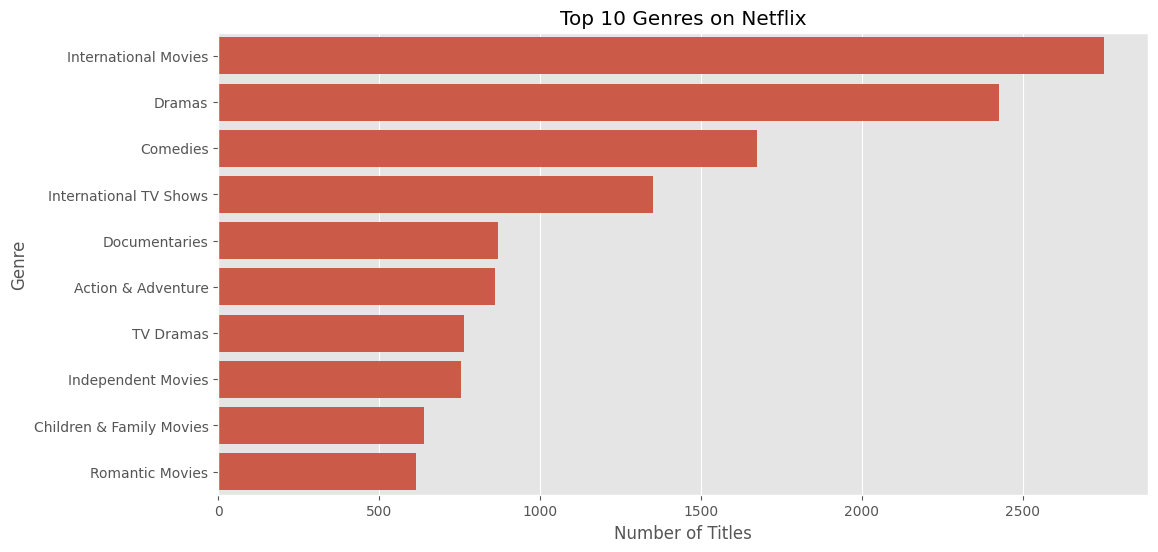

In [35]:
# Split genres and count titles
genre_counts = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

The analysis shows that International Movies is the most common genre on Netflix, followed by Dramas and Comedies. International TV Shows and Documentaries also contribute significantly to the catalog. This indicates that the dataset contains a diverse range of genres, with international content and drama being particularly prominent.

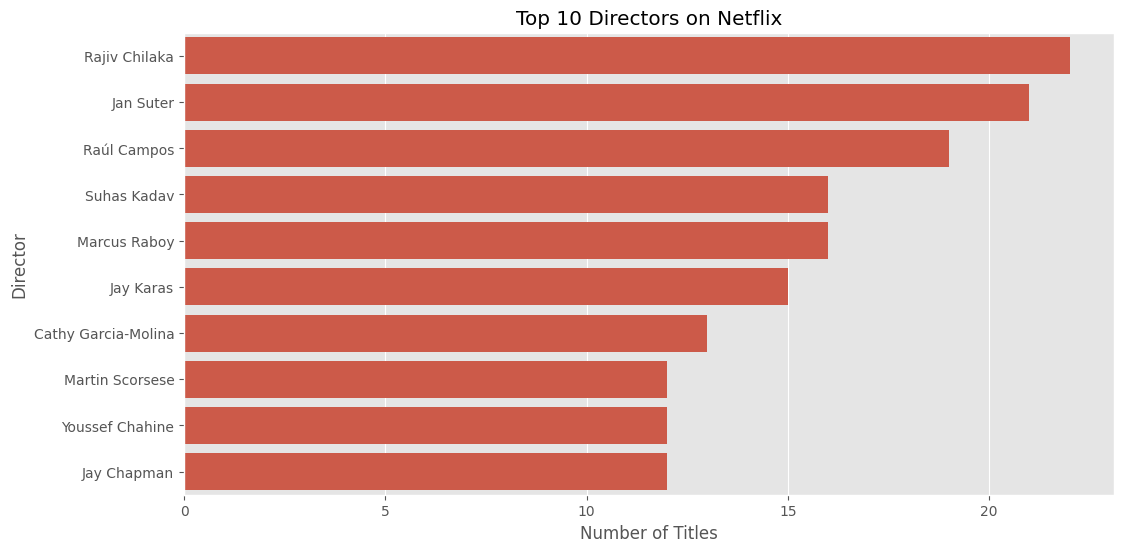

In [36]:
# Count titles by director
director_counts = (
    df["director"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=director_counts.values,
    y=director_counts.index
)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

The analysis shows that Rajiv Chilaka has the highest number of titles among the top 10 directors, followed by Jan Suter and Raúl Campos. The chart highlights the directors with the largest number of titles in the Netflix dataset.

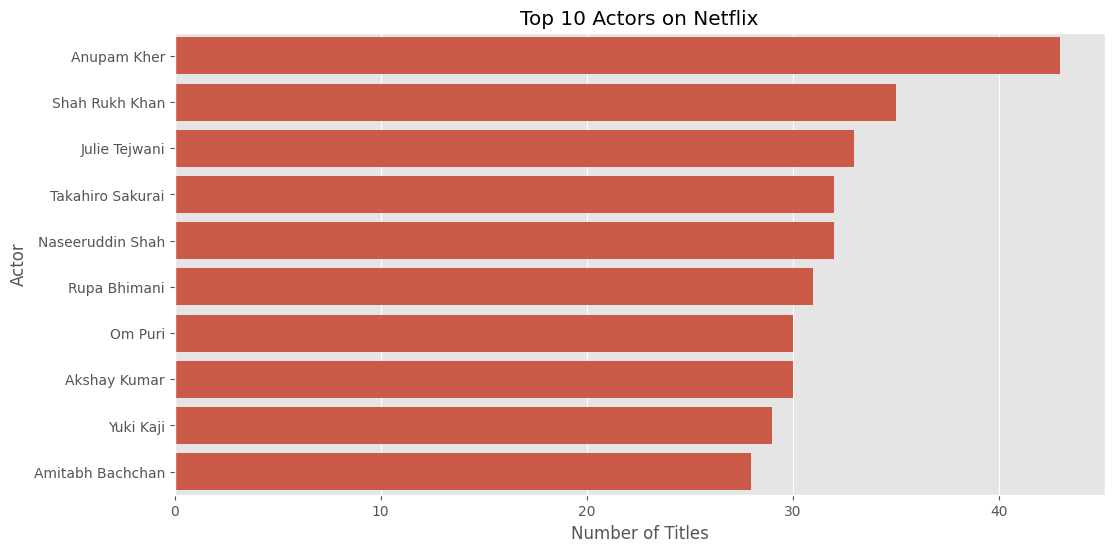

In [37]:
# Count actors across all titles
actor_counts = (
    df["cast"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=actor_counts.values,
    y=actor_counts.index
)

plt.title("Top 10 Actors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")
plt.show()

The analysis shows that Anupam Kher has the highest number of appearances among the top 10 actors in the Netflix dataset, followed by Shah Rukh Khan and Julie Tejwani. The chart highlights actors who have appeared in multiple Netflix titles

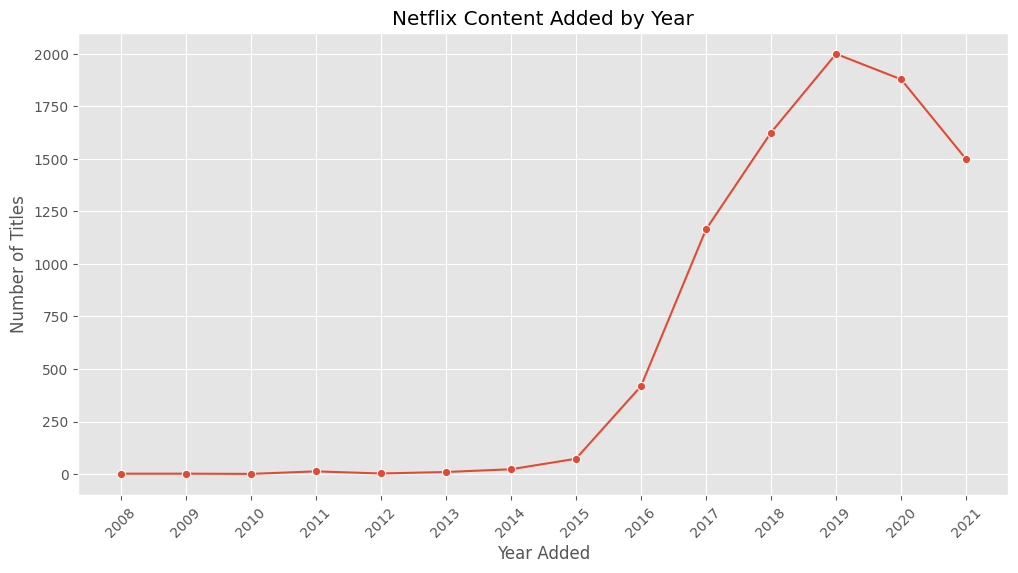

In [38]:
# Extract year from date_added
df["year_added"] = df["date_added"].dt.year

# Count titles added each year
year_counts = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    marker="o"
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.xticks(year_counts.index, rotation=45)
plt.grid(True)

plt.show()

The analysis shows a significant increase in the number of titles added to Netflix from 2015 onward. The highest number of titles was added in 2019, followed by a decline in 2020 and 2021. This indicates that the dataset contains a large concentration of titles added during the 2017–2021 period.

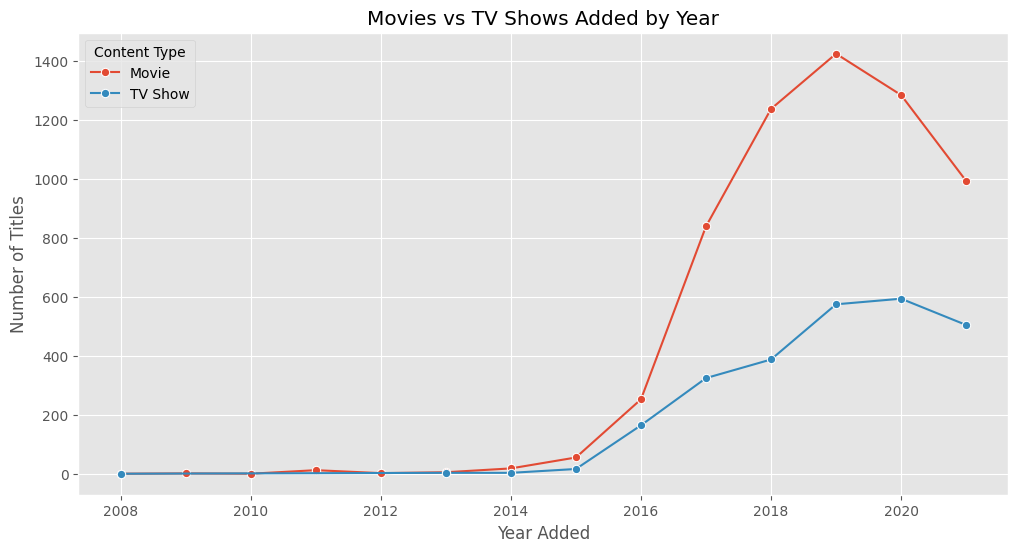

In [39]:
# Group content by year and type
year_type = (
    df.dropna(subset=["year_added"])
    .groupby(["year_added", "type"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=year_type,
    x="year_added",
    y="count",
    hue="type",
    marker="o"
)

plt.title("Movies vs TV Shows Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")
plt.show()

The analysis shows that Netflix added more movies than TV shows throughout most of the observed period. Content additions increased significantly after 2015, with movies peaking in 2019 and TV shows peaking in 2020. A decline in additions is visible in 2021.

In [40]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['type'], df['rating'])

# Perform the Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

# Interpret the result
if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("Content type and content rating are significantly associated.")
else:
    print("Fail to reject the null hypothesis.")
    print("No statistically significant association was found.")

Chi-Square Statistic: 1046.1838409436073
P-value: 2.0970397547261396e-215
Degrees of Freedom: 13
Reject the null hypothesis.
Content type and content rating are significantly associated.


The Chi-Square Test of Independence was performed to examine the relationship between content type and content rating on Netflix. The test produced a Chi-Square statistic of 1046.18, with 13 degrees of freedom and a p-value of 2.097 × 10⁻²¹⁵. Since the p-value is below the 0.05 significance level, the null hypothesis was rejected. The results indicate a statistically significant association between content type and content rating.

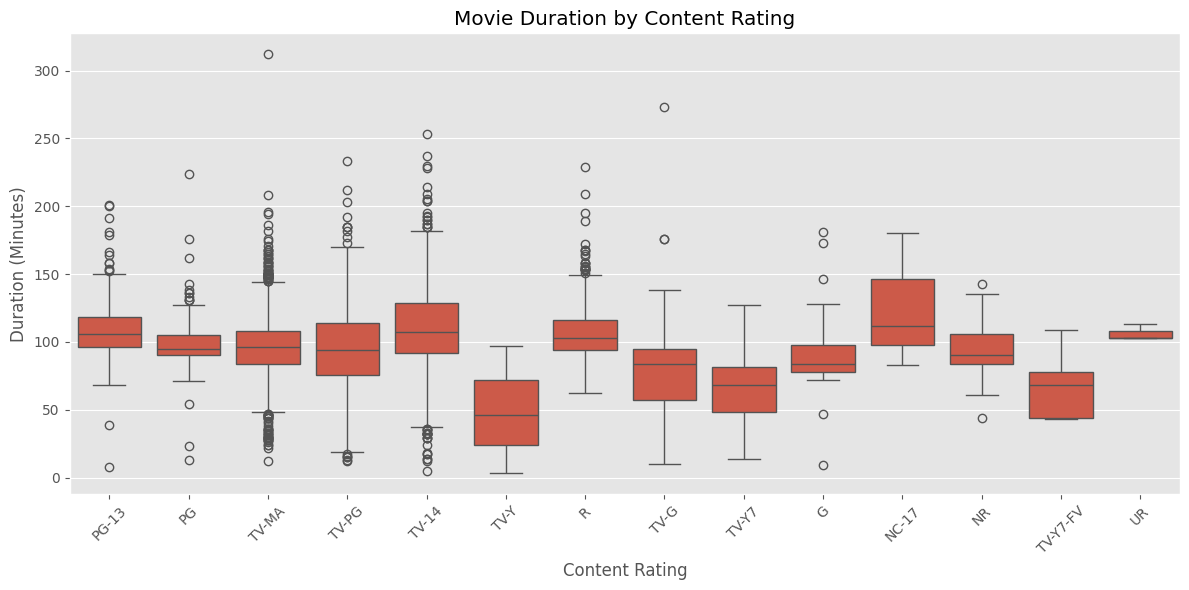

In [41]:
# Extract movie data
movies = df[df['type'] == 'Movie'].copy()

# Extract duration in minutes
movies['duration_minutes'] = (
    movies['duration'].str.extract(r'(\d+)').astype(float)
)

# Create a box plot
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=movies,
    x='rating',
    y='duration_minutes'
)

plt.title('Movie Duration by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Duration (Minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The box plot shows that movie durations vary across content ratings. Most ratings have median durations between approximately 80 and 110 minutes, while TV-Y and TV-Y7-FV movies generally have shorter durations. Several ratings contain unusually long or short movies, indicating the presence of outliers.

In [42]:
from scipy.stats import kruskal

# Remove missing values
duration_data = movies.dropna(
    subset=['rating', 'duration_minutes']
)

# Group movie durations by rating
groups = [
    group['duration_minutes'].values
    for rating, group in duration_data.groupby('rating')
    if len(group) > 1
]

# Perform Kruskal-Wallis test
statistic, p_value = kruskal(*groups)

print("Kruskal-Wallis Statistic:", statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("Movie durations differ significantly across ratings.")
else:
    print("Fail to reject the null hypothesis.")
    print("No significant difference was detected.")

Kruskal-Wallis Statistic: 965.8466622925107
P-value: 3.7682246902139096e-198
Reject the null hypothesis.
Movie durations differ significantly across ratings.


The Kruskal–Wallis test was performed to determine whether movie durations differ across content ratings. The test yielded a statistic of 965.85 and a p-value of 3.768 × 10⁻¹⁹⁸. Since the p-value is below the 0.05 significance level, the null hypothesis was rejected. The results indicate that movie-duration distributions differ significantly across content ratings.

In [43]:
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Group durations by rating
rating_groups = {
    rating: group['duration_minutes'].values
    for rating, group in duration_data.groupby('rating')
    if len(group) >= 2
}

# Perform pairwise tests
results = []

for rating1, rating2 in combinations(rating_groups.keys(), 2):
    stat, p = mannwhitneyu(
        rating_groups[rating1],
        rating_groups[rating2],
        alternative='two-sided'
    )

    results.append([rating1, rating2, stat, p])

# Apply Holm correction
results_df = pd.DataFrame(
    results,
    columns=['Rating 1', 'Rating 2', 'U Statistic', 'P-value']
)

results_df['Adjusted P-value'] = multipletests(
    results_df['P-value'],
    method='holm'
)[1]

results_df['Significant'] = (
    results_df['Adjusted P-value'] < 0.05
)

display(results_df.sort_values('Adjusted P-value'))

,Rating 1,Rating 2,U Statistic,P-value,Adjusted P-value,Significant
59,R,TV-Y,103191.0,6.059383e-72,5.514039e-70,True
66,TV-14,TV-Y,178076.0,4.503598e-66,4.053238e-64,True
51,PG-13,TV-Y,63370.5,6.492037e-66,5.777913e-64,True
60,R,TV-Y7,103494.5,3.815382e-60,3.357536e-58,True
77,TV-MA,TV-Y,249347.0,1.770170e-59,1.540048e-57,True
...,...,...,...,...,...,...
84,TV-PG,UR,540.0,3.199436e-01,1.000000e+00,False
80,TV-MA,UR,1786.0,2.054561e-01,1.000000e+00,False
86,TV-Y,TV-Y7-FV,198.0,1.354415e-01,1.000000e+00,False
88,TV-Y7,TV-Y7-FV,355.5,9.347441e-01,1.000000e+00,False


In [46]:
# Find all DataFrames currently available
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(name, obj.shape)

_ (4, 10)
__ (8, 2)
___ (5, 12)
df (8807, 13)
tv (2676, 13)
missing (12, 2)
table (2, 17)
_18 (5, 12)
_22 (8, 2)
_23 (4, 10)
movies (6131, 14)
tv_shows (2676, 13)
year_type (24, 3)
contingency_table (2, 14)
duration_data (6126, 14)
results_df (91, 6)


In [47]:
print("Total comparisons:", len(results_df))

print("\nSignificant vs Non-significant:")
print(results_df["Significant"].value_counts())

Total comparisons: 91

Significant vs Non-significant:
Significant
False    48
True     43
Name: count, dtype: int64


In [48]:
non_significant = results_df[results_df["Significant"] == False]

print("Non-significant comparisons:")
display(non_significant)

Non-significant comparisons:


,Rating 1,Rating 2,U Statistic,P-value,Adjusted P-value,Significant
0,G,NC-17,28.5,0.129304,1.000000,False
1,G,NR,1181.0,0.039683,1.000000,False
6,G,TV-G,3009.0,0.113478,1.000000,False
7,G,TV-MA,31668.5,0.005886,0.258970,False
8,G,TV-PG,9076.0,0.054358,1.000000,False
11,G,TV-Y7-FV,155.5,0.063144,1.000000,False
12,G,UR,17.0,0.040016,1.000000,False
13,NC-17,NR,153.0,0.298369,1.000000,False
14,NC-17,PG,549.5,0.411924,1.000000,False
15,NC-17,PG-13,815.5,0.744968,1.000000,False


In [49]:
significant_count = (results_df["Significant"] == True).sum()

print("Significant comparisons:", significant_count)
print("Non-significant comparisons:", len(non_significant))

Significant comparisons: 43
Non-significant comparisons: 48


Pairwise Comparison Analysis

Following the Kruskal–Wallis test, pairwise Mann–Whitney U tests were conducted to identify differences in movie durations across content ratings. Out of 91 pairwise comparisons, 43 were statistically significant, while 48 were not significant after multiple-comparison correction. These results indicate that movie-duration distributions differ significantly between certain rating groups, but not all rating groups.

Out of 91 pairwise comparisons between movie content ratings, 43 showed statistically significant differences in movie-duration distributions, while 48 did not show statistically significant differences after Holm correction. This indicates that movie durations differ significantly between certain rating groups, but not all groups.

Final Conclusion

The Netflix dataset analysis revealed several key insights:

Content Type: Movies dominate the Netflix catalog, accounting for approximately 69.6% of titles, while TV Shows make up 30.4%.

Content Growth: Netflix content releases and additions increased significantly after 2015, with content additions peaking around 2019.

Ratings: TV-MA is the most common rating, followed by TV-14.

Movie Duration: Most movies have a runtime of approximately 80–120 minutes.

TV Shows: Most TV Shows have only one season.

Countries and Genres: The United States contributes the largest number of titles. International Movies, Dramas, and Comedies are among the most frequent genres.

Hypothesis Testing: The Chi-square test found a statistically significant association between content type and rating. The Kruskal-Wallis test also found significant differences in movie durations across ratings.

Pairwise Analysis: Of 91 pairwise comparisons, 43 were statistically significant after Holm correction, while 48 were not.

Overall, the analysis highlights the distribution, growth, genres, ratings, and duration patterns of Netflix's catalog.